In [35]:
import pandas as pd
import numpy as np

In [36]:
df=pd.read_csv("/content/Copy of Churn_Modelling.csv")

In [37]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [67]:
q1=df['CreditScore'].quantile(0.25)
q3=df['Age'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df['CreditScore'] = df['Age'].clip(
    lower=lower_bound,
    upper=upper_bound
)
df['Age'] = df['Age'].clip(
    lower=lower_bound,
    upper=upper_bound
)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,42,0,0,42,2,0.00,1,1,1,101348.88,1
1,41,2,0,41,1,83807.86,1,0,1,112542.58,0
2,42,0,0,42,8,159660.80,3,1,0,113931.57,1
3,39,0,0,39,1,0.00,2,0,0,93826.63,0
4,43,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,39,0,1,39,5,0.00,2,1,0,96270.64,0
9996,35,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,36,0,0,36,7,0.00,1,0,1,42085.58,1
9998,42,1,1,42,3,75075.31,2,1,0,92888.52,1


<Axes: >

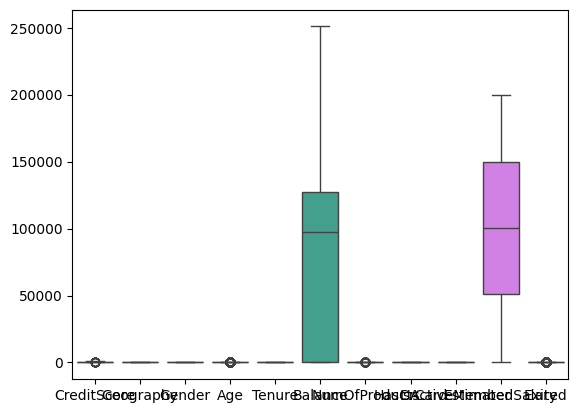

In [62]:
sns.boxplot(df)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [46]:
!pip install missingno

<function matplotlib.pyplot.show(close=None, block=None)>

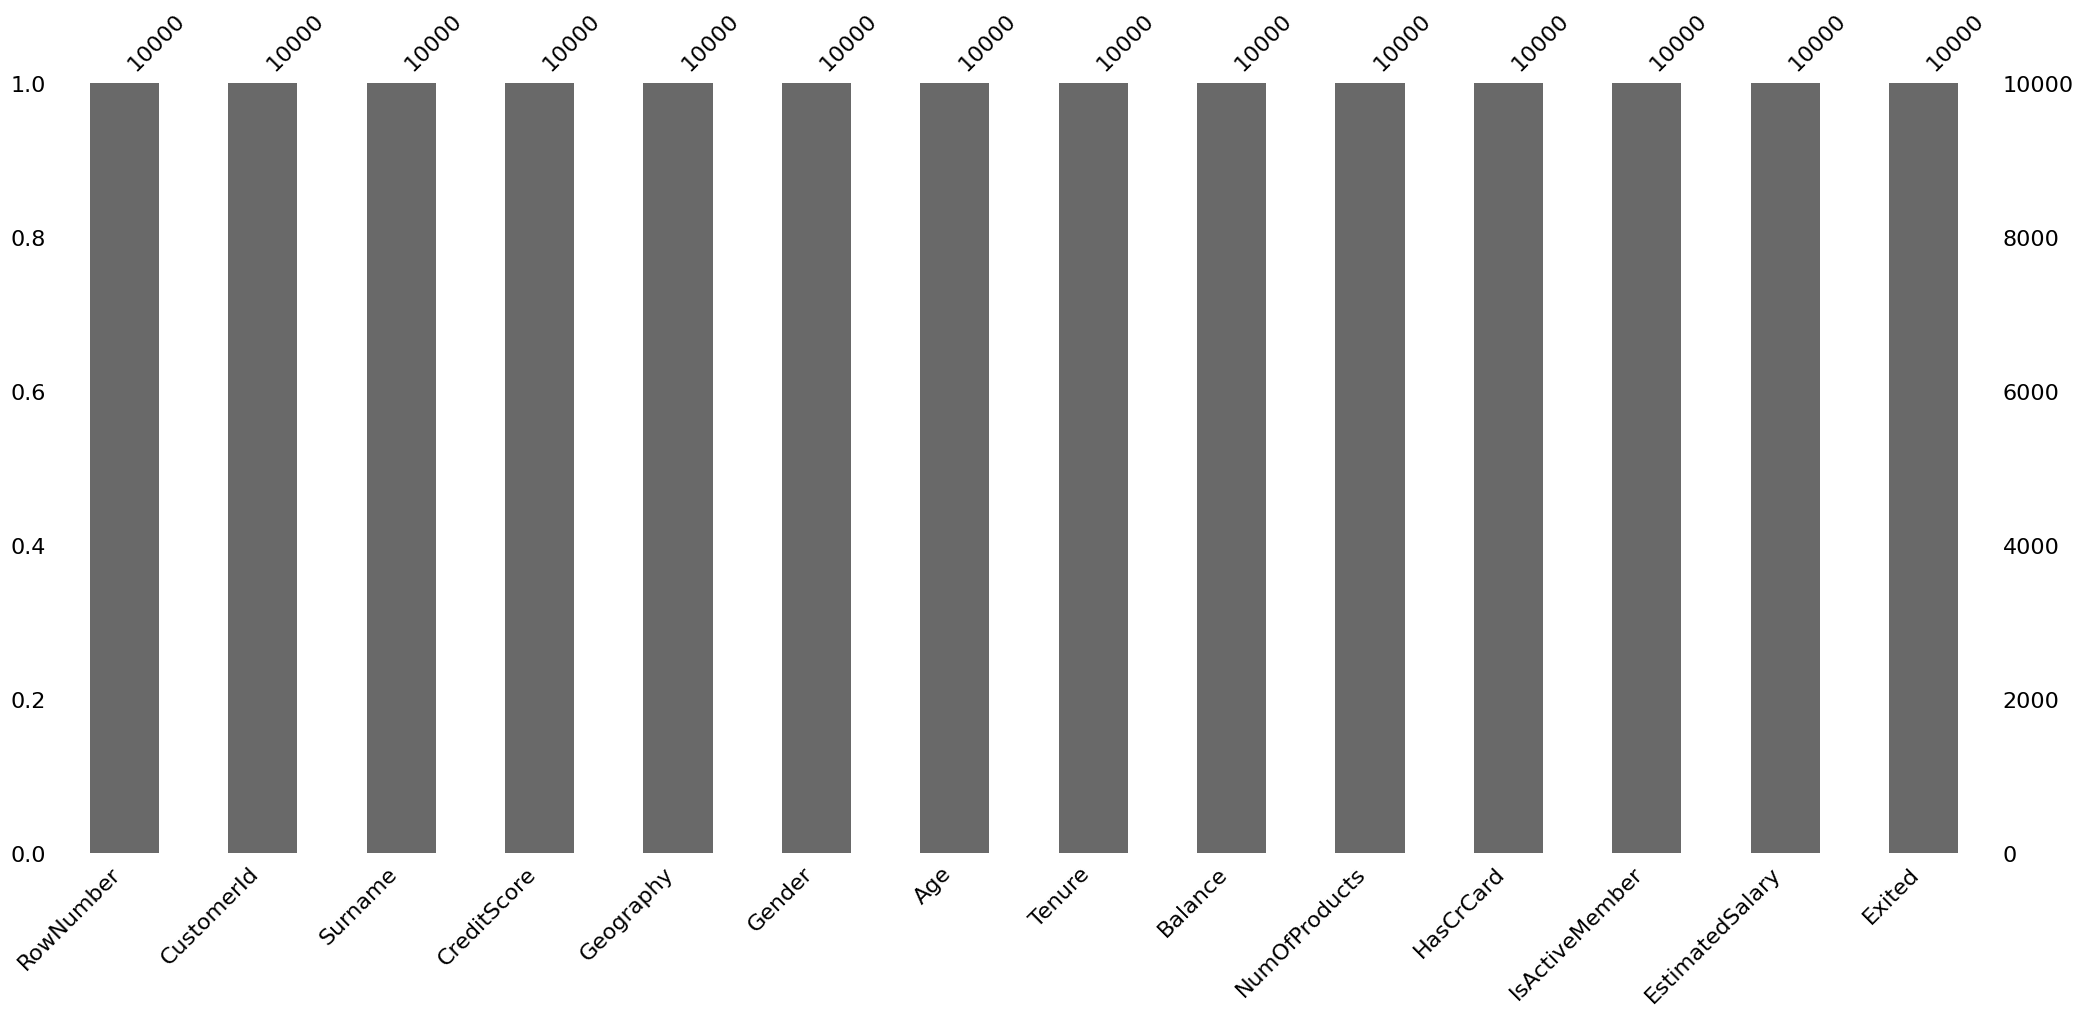

In [47]:
import missingno as msno
import matplotlib.pyplot as plt
msno.bar(df)
plt.show

In [48]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1 , inplace=True)

<Axes: >

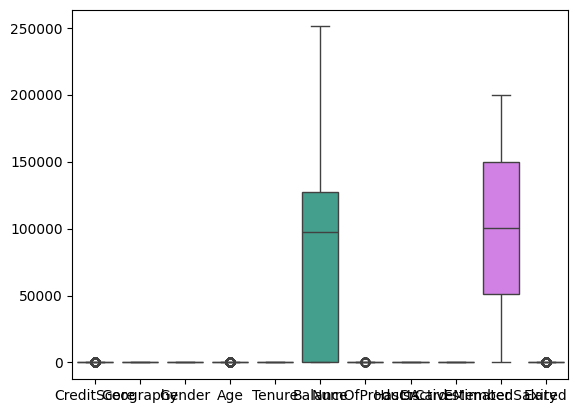

In [69]:
sns.boxplot(df)

In [71]:
q1=df['CreditScore'].quantile(0.25)
q3=df['Age'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df['Age'] = df['Age'].clip(
    lower=lower_bound,
    upper=upper_bound
)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,42,0,0,42,2,0.00,1,1,1,101348.88,1
1,41,2,0,41,1,83807.86,1,0,1,112542.58,0
2,42,0,0,42,8,159660.80,3,1,0,113931.57,1
3,39,0,0,39,1,0.00,2,0,0,93826.63,0
4,43,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,39,0,1,39,5,0.00,2,1,0,96270.64,0
9996,35,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,36,0,0,36,7,0.00,1,0,1,42085.58,1
9998,42,1,1,42,3,75075.31,2,1,0,92888.52,1


<Axes: >

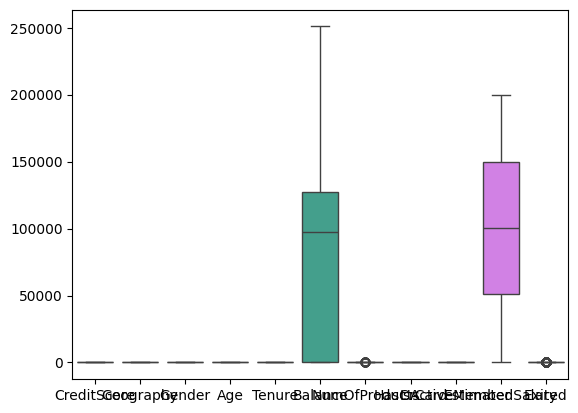

In [72]:
sns.boxplot(df)

In [84]:
q1=df['NumOfProducts'].quantile(0.25)
q3=df['EstimatedSalary'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df['NumOfProducts'] = df['EstimatedSalary'].clip(
    lower=lower_bound,
    upper=upper_bound
)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,42,0,0,42,2,0.00,101348.88,1,1,101348.88,1
1,41,2,0,41,1,83807.86,112542.58,0,1,112542.58,0
2,42,0,0,42,8,159660.80,113931.57,1,0,113931.57,1
3,39,0,0,39,1,0.00,93826.63,0,0,93826.63,0
4,43,2,0,43,2,125510.82,79084.10,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,39,0,1,39,5,0.00,96270.64,1,0,96270.64,0
9996,35,0,1,35,10,57369.61,101699.77,1,1,101699.77,0
9997,36,0,0,36,7,0.00,42085.58,0,1,42085.58,1
9998,42,1,1,42,3,75075.31,92888.52,1,0,92888.52,1


<Axes: >

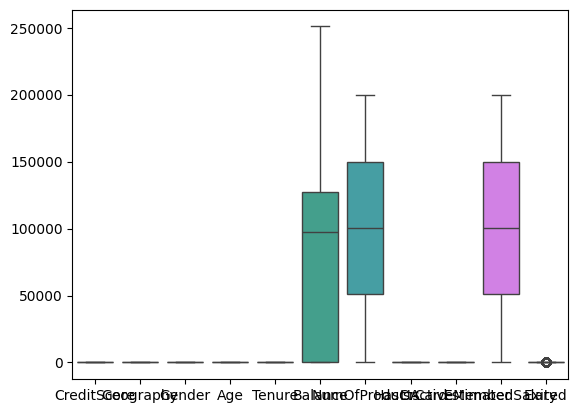

In [85]:
sns.boxplot(df)

In [49]:
le=LabelEncoder()
df['Geography']=le.fit_transform(df['Geography'])
df['Gender']=le.fit_transform(df['Gender'])
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [50]:
X=df.drop('Exited',axis=1)
y=df['Exited']
X_train , X_test , y_train,y_test=train_test_split(X,y, test_size=0.2 , random_state=42)

In [51]:
model=GaussianNB()
model

GaussianNB()

In [52]:
model.fit(X_train, y_train)


GaussianNB()

In [53]:
y_pred = model.predict(X_test)


In [54]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.79


In [55]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[1553   54]
 [ 366   27]]


In [56]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1607
           1       0.33      0.07      0.11       393

    accuracy                           0.79      2000
   macro avg       0.57      0.52      0.50      2000
weighted avg       0.72      0.79      0.73      2000

